In [1]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
DRIVE_URL = '/content/drive/MyDrive/radar_base_general_aleman_ramirez'
LOCAL_PATH = os.getcwd()

In [3]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [4]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [5]:
SCALED = os.path.join(BASE, "scaled")
FILTERED = os.path.join(BASE, "filtered")
CLUSTER = os.path.join(BASE, "cluster")

os.makedirs(CLUSTER, exist_ok=True)

print("Base:", BASE)
print("SCALED:", SCALED)
print("FILTERED:", FILTERED)
print("CLUSTER:", CLUSTER)

Base: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree
SCALED: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled
FILTERED: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered
CLUSTER: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\cluster


In [6]:
nombre_base = "2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0"

ruta_unfiltered = os.path.join(SCALED, nombre_base + "_scaled.tiff")
ruta_filtered = os.path.join(FILTERED, nombre_base + "_scaled_lee.tiff")

img_unfiltered = cv2.imread(ruta_unfiltered, cv2.IMREAD_UNCHANGED)
img_filtered = cv2.imread(ruta_filtered, cv2.IMREAD_UNCHANGED)

if len(img_unfiltered.shape) == 3:
    img_unfiltered = img_unfiltered[:, :, 0]

if len(img_filtered.shape) == 3:
    img_filtered = img_filtered[:, :, 0]

print("Sin filtrar:", img_unfiltered.shape, img_unfiltered.dtype)
print("Filtrada:", img_filtered.shape, img_filtered.dtype)

Sin filtrar: (2500, 1541) uint8
Filtrada: (2500, 1541) uint8


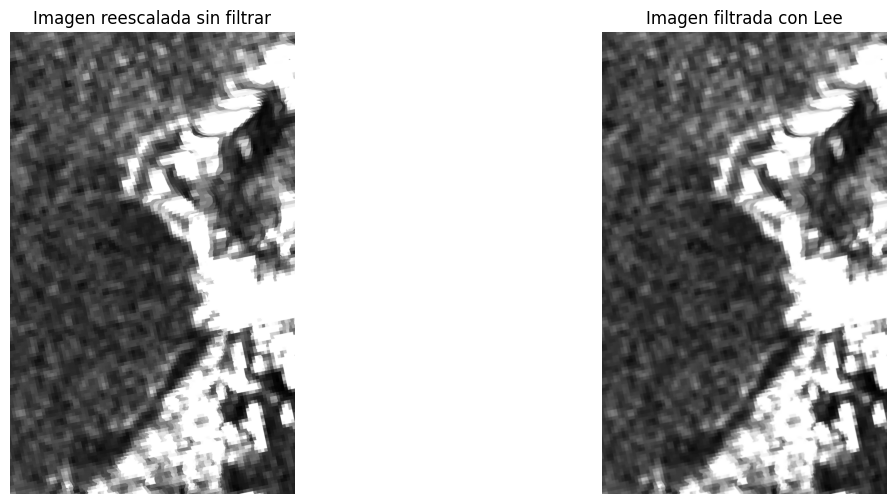

In [7]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_unfiltered, cmap="gray")
plt.title("Imagen reescalada sin filtrar")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_filtered, cmap="gray")
plt.title("Imagen filtrada con Lee")
plt.axis("off")

plt.show()

In [8]:
def kmeans_grayscale(img, k=3, random_state=42):
    """
    Aplica K-Means a una imagen en escala de grises.
    Devuelve:
    - imagen clasificada en niveles de gris
    - etiquetas por píxel
    - centros ordenados
    """
    h, w = img.shape
    X = img.reshape(-1, 1).astype(np.float32)

    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_.flatten()

    # ordenar centros de menor a mayor intensidad
    order = np.argsort(centers)

    # asignar niveles de gris entre 0 y 255
    gray_levels = np.linspace(0, 255, k).astype(np.uint8)

    remap = np.zeros(k, dtype=np.uint8)
    for new_idx, old_idx in enumerate(order):
        remap[old_idx] = gray_levels[new_idx]

    img_cluster = remap[labels].reshape(h, w)
    centers_sorted = centers[order]

    return img_cluster, labels.reshape(h, w), centers_sorted

Centros ordenados sin filtrar, k=3: [ 46.611378  97.57483  182.84802 ]


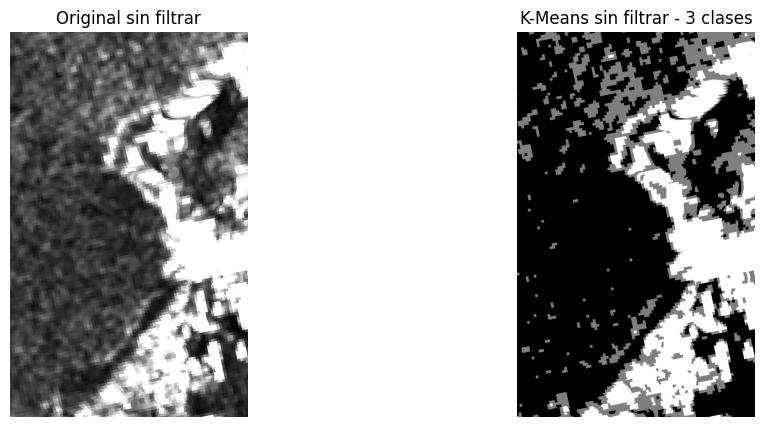

In [9]:
cluster_unf_3, labels_unf_3, centers_unf_3 = kmeans_grayscale(img_unfiltered, k=3)

print("Centros ordenados sin filtrar, k=3:", centers_unf_3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_unfiltered, cmap="gray")
plt.title("Original sin filtrar")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cluster_unf_3, cmap="gray")
plt.title("K-Means sin filtrar - 3 clases")
plt.axis("off")

plt.show()

Centros ordenados filtrada, k=3: [ 47.11058  98.76961 181.951  ]


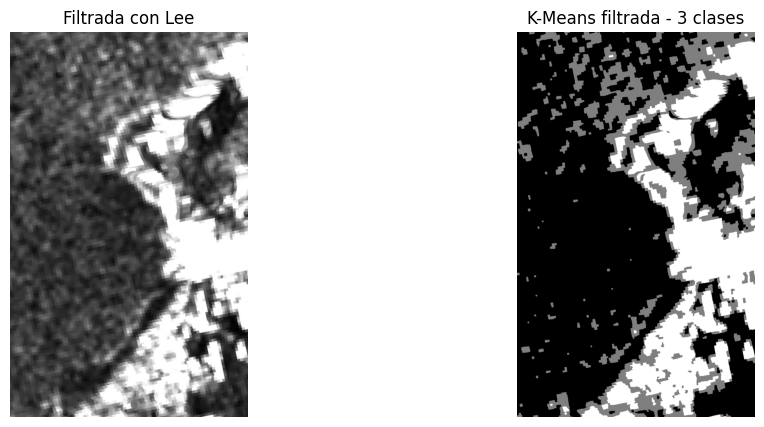

In [10]:
cluster_flt_3, labels_flt_3, centers_flt_3 = kmeans_grayscale(img_filtered, k=3)

print("Centros ordenados filtrada, k=3:", centers_flt_3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_filtered, cmap="gray")
plt.title("Filtrada con Lee")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cluster_flt_3, cmap="gray")
plt.title("K-Means filtrada - 3 clases")
plt.axis("off")

plt.show()

Centros ordenados filtrada, k=3: [ 47.11058  98.76961 181.951  ]


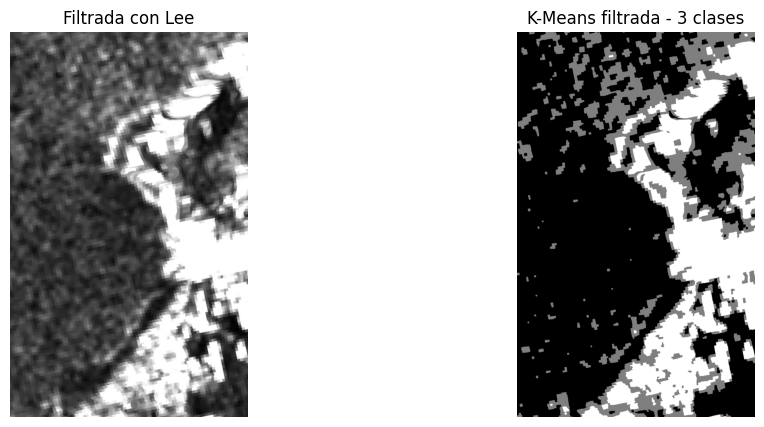

In [11]:
cluster_flt_3, labels_flt_3, centers_flt_3 = kmeans_grayscale(img_filtered, k=3)

print("Centros ordenados filtrada, k=3:", centers_flt_3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_filtered, cmap="gray")
plt.title("Filtrada con Lee")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cluster_flt_3, cmap="gray")
plt.title("K-Means filtrada - 3 clases")
plt.axis("off")

plt.show()

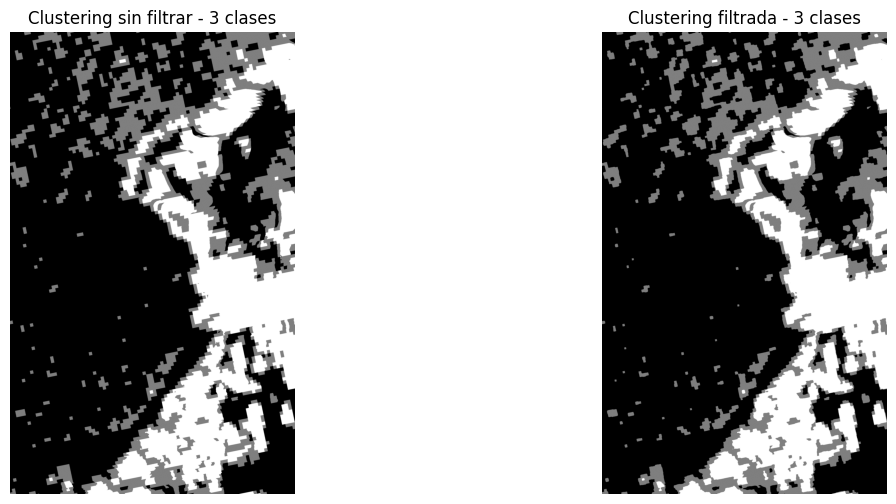

In [12]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cluster_unf_3, cmap="gray")
plt.title("Clustering sin filtrar - 3 clases")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cluster_flt_3, cmap="gray")
plt.title("Clustering filtrada - 3 clases")
plt.axis("off")

plt.show()

In [ ]:
cluster_unf_4, labels_unf_4, centers_unf_4 = kmeans_grayscale(img_unfiltered, k=4)
cluster_flt_4, labels_flt_4, centers_flt_4 = kmeans_grayscale(img_filtered, k=4)

print("Centros ordenados sin filtrar, k=4:", centers_unf_4)
print("Centros ordenados filtrada, k=4:", centers_flt_4)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(cluster_unf_4, cmap="gray")
plt.title("Sin filtrar - 4 clases")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cluster_flt_4, cmap="gray")
plt.title("Filtrada - 4 clases")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_unfiltered, cmap="gray")
plt.title("Original sin filtrar")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_filtered, cmap="gray")
plt.title("Original filtrada")
plt.axis("off")

plt.show()

In [13]:
cv2.imwrite(os.path.join(CLUSTER, "cluster_unfiltered_k3.tiff"), cluster_unf_3)
cv2.imwrite(os.path.join(CLUSTER, "cluster_filtered_k3.tiff"), cluster_flt_3)
cv2.imwrite(os.path.join(CLUSTER, "cluster_unfiltered_k4.tiff"), cluster_unf_4)
cv2.imwrite(os.path.join(CLUSTER, "cluster_filtered_k4.tiff"), cluster_flt_4)

print("Resultados guardados en:", CLUSTER)

Resultados guardados en: /content/drive/MyDrive/radar_base_general_aleman_ramirez/cluster


In [14]:
def resumen_clases(labels, nombre=""):
    valores, conteos = np.unique(labels, return_counts=True)
    total = labels.size

    print(f"\nResumen de clases - {nombre}")
    for v, c in zip(valores, conteos):
        print(f"Clase {v}: {c} píxeles ({100 * c / total:.2f}%)")


resumen_clases(labels_unf_3, "Sin filtrar k=3")
resumen_clases(labels_flt_3, "Filtrada k=3")
resumen_clases(labels_unf_4, "Sin filtrar k=4")
resumen_clases(labels_flt_4, "Filtrada k=4")


Resumen de clases - Sin filtrar k=3
Clase 0: 777413 píxeles (20.18%)
Clase 1: 804195 píxeles (20.87%)
Clase 2: 2270892 píxeles (58.95%)

Resumen de clases - Filtrada k=3
Clase 0: 725156 píxeles (18.82%)
Clase 1: 2330497 píxeles (60.49%)
Clase 2: 796847 píxeles (20.68%)

Resumen de clases - Sin filtrar k=4
Clase 0: 1149829 píxeles (29.85%)
Clase 1: 718762 píxeles (18.66%)
Clase 2: 1558057 píxeles (40.44%)
Clase 3: 425852 píxeles (11.05%)

Resumen de clases - Filtrada k=4
Clase 0: 1162338 píxeles (30.17%)
Clase 1: 734365 píxeles (19.06%)
Clase 2: 1510748 píxeles (39.21%)
Clase 3: 445049 píxeles (11.55%)
